In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH
from nrem_sc.utils import plot_intervals

import numpy as np
import pynapple as nap

from replay_trajectory_classification import (
    SortedSpikesDecoder,
    Environment,
    RandomWalk,
    make_track_graph,
)

unit_id = '116b'

def get_environment(num_nodes: int = 360, place_bin_size: float = 1.0):
    radius = 180 / np.pi
    angle = np.linspace(2 * np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    n_nodes = len(track_graph.nodes)
    edge_order = np.stack(
        (np.roll(np.arange(n_nodes - 1, -1, -1), 1),
         np.arange(n_nodes - 1, -1, -1)),
        axis=1,
    )

    return Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=0,
    )

# Load data
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

(<Figure size 2200x300 with 1 Axes>, <Axes: xlabel='Time (s)'>)

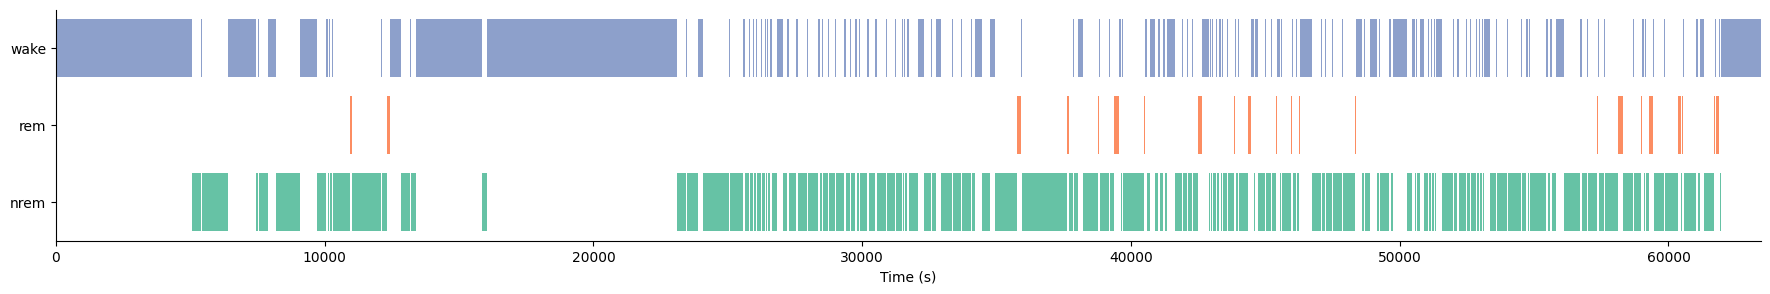

In [2]:
plot_intervals(sleep_states, column='state', palette='Set2', figsize=(22, 3))

(<Figure size 2200x300 with 1 Axes>, <Axes: xlabel='Time (s)'>)

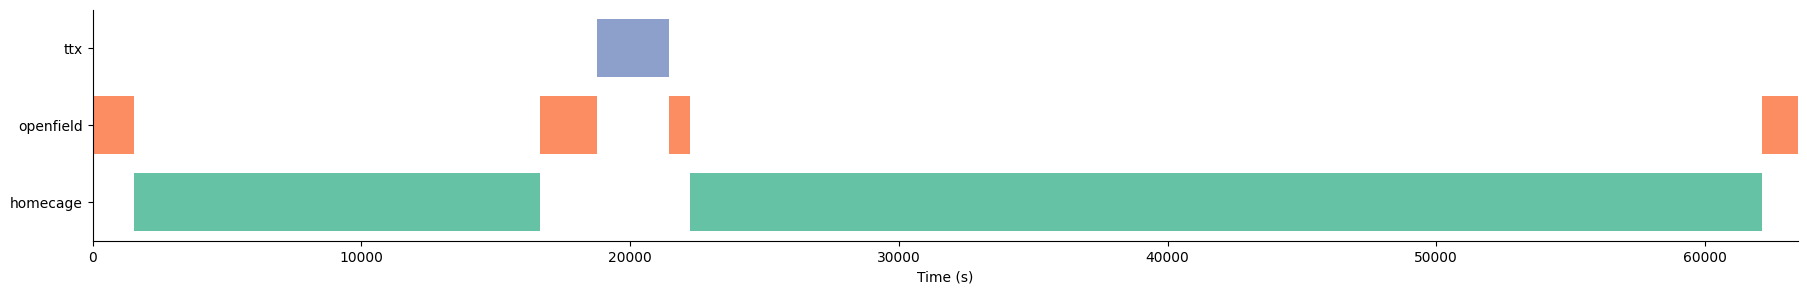

In [3]:
plot_intervals(sessions, column='label', palette='Set2', figsize=(22, 3))

In [2]:
environment = get_environment(num_nodes=360, place_bin_size=1.0)
decoder = SortedSpikesDecoder(
    environment=environment,
    transition_type=RandomWalk(movement_var=2.0),
)

In [3]:
bin_size_ms = 2
train_ep = hd_angle.time_support

spikes = hd_spikes.count(bin_size=bin_size_ms, ep=train_ep, time_units="ms").astype(np.bool_)
angle = hd_angle.bin_average(bin_size=bin_size_ms, ep=train_ep, time_units="ms").to_numpy()

print(spikes.shape, angle.shape)

(1054770, 81) (1054770,)


In [4]:
decoder.fit(angle, spikes.to_numpy())

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


,environment,Environment(e...t_threshold=0)
,transition_type,RandomWalk(en...ffusion=False)
,initial_conditions_type,UniformInitialConditions()
,infer_track_interior,True
,sorted_spikes_algorithm,'spiking_likelihood_kde'
,sorted_spikes_algorithm_params,"{'block_size': None, 'position_std': 6.0, 'use_diffusion': False}"


Text(0, 0.5, 'Firing Rate')

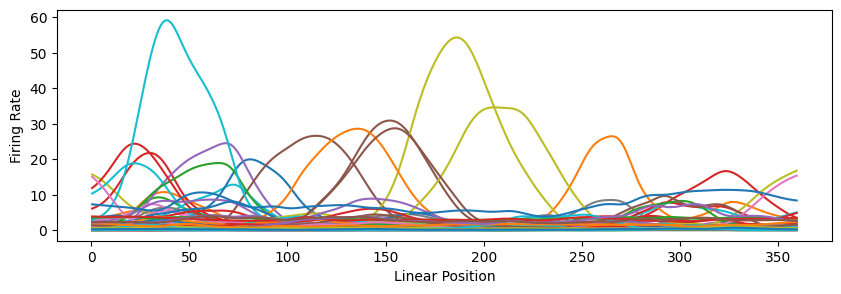

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
(decoder.place_fields_ * spikes.rate).plot(x="position", hue="neuron", add_legend=False, ax=ax)
ax.set_xlabel('Linear Position')
ax.set_ylabel('Firing Rate')

In [6]:
pre_rem = sleep_states[sleep_states['state'] == 'rem'].intersect(sessions[sessions['label'] == 'homecage'][0])
post_rem = sleep_states[sleep_states['state'] == 'rem'].intersect(sessions[sessions['label'] == 'homecage'][1])

spike_counts = hd_spikes.restrict(pre_rem).count(bin_size=bin_size_ms, time_units="ms").astype(np.bool_)
decoded_pre = decoder.predict(spike_counts.values, time=spike_counts.times())

spike_counts = hd_spikes.restrict(post_rem).count(bin_size=bin_size_ms, time_units="ms").astype(np.bool_)
decoded_post = decoder.predict(spike_counts.values, time=spike_counts.times())    

  0%|          | 0/81 [00:00<?, ?it/s]

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:87: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  posterior[k] = state_transition.T @ posterior[k - 1] * likelihood[k]
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\replay_trajectory_classification\core.py:119: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  acausal_prior = state_transition.T @ causal_posterior[time_ind]


  0%|          | 0/81 [00:00<?, ?it/s]

In [7]:
decoded_pre = nap.Tsd(t=decoded_pre['time'].to_numpy(), d=decoded_pre.acausal_posterior.idxmax(dim="position").to_numpy())
decoded_post = nap.Tsd(t=decoded_post['time'].to_numpy(), d=decoded_post.acausal_posterior.idxmax(dim="position").to_numpy())

In [8]:
decoded_post

Time (s)
----------  --------
33336.001   130.498
33336.003   130.498
33336.005   130.498
33336.007   130.498
33336.009   131.498
33336.011   131.498
33336.013   131.498
...
61968.987    18.4998
61968.989    18.4998
61968.991    18.4998
61968.993    18.4998
61968.995    18.4998
61968.997    18.4998
61968.999    18.4998
dtype: float64, shape: (850500,)

In [14]:
import pandas as pd

data = {'duration': [], 'net_displacement': [], 'path_length': [], 'integral': [], 'n_samples': [], 'condition': []}
window = 1


for decoded in [decoded_pre, decoded_post]:
    t = np.arange(start=decoded.t[0], stop=decoded.t[-1], step=window)
    epochs = nap.IntervalSet(start=t[::2], end=t[::2]+window)
    
    for ep in epochs:
        d = decoded.restrict(ep)
        if len(d) == 0:
            continue

        uw = np.unwrap(d.d, period=360)
        durations = d.t[-1] - d.t[0]
        net_displacement = np.diff(uw).sum()
        path_length = np.abs(np.diff(uw)).sum()
        integral = np.sum(d.d - d.d[0])
        n_samples = len(d)

        if d.t[-1] < sessions[sessions['label'] == 'ttx']['start']:
            condition = 'pre'
        elif d.t[0] > sessions[sessions['label'] == 'ttx']['end']:
            condition = 'post'

        for key, value in zip(data.keys(), [durations, net_displacement, path_length, integral, n_samples, condition]):
            data[key].append(value)

df = pd.DataFrame(data)
df

,duration,net_displacement,path_length,integral,n_samples,condition
0,1.000,17.999772,33.999568,3356.957392,501,pre
1,1.000,0.999987,82.998947,3988.949370,501,pre
2,1.000,-14.999810,46.999403,-2445.968955,501,pre
3,1.000,2.999962,34.999556,1856.976430,501,pre
4,1.000,-1.999975,49.999365,2350.970160,501,pre
...,...,...,...,...,...,...
968,1.000,46.999403,96.998769,16691.788139,501,post
969,1.000,-1.999975,37.999518,-650.991737,501,post
970,1.000,3.999949,63.999188,2119.973092,501,post
971,1.000,-6.999911,50.999353,2654.966302,501,post


In [15]:
df['net_displacement'].describe()

count    973.000000
mean      14.629022
std       56.158595
min     -290.996307
25%       -8.999886
50%        7.999898
75%       37.999518
max      280.001015
Name: net_displacement, dtype: float64

In [16]:
df.to_csv(PROCESSED_DATA_PATH / unit_id / "decoded_rem_sweep_metrics_2s_window.csv", index=False)